# 3. Integrated Consumption & Environmental Dataset

## Overview
This notebook merges consumption/energy community data with environmental variables to create a complete modeling dataset. It intelligently handles missing environmental data through spatial and administrative mapping techniques.

### Inputs
- `1_EnergyComunities&Consumption_output/dataset_final_parish_amp_FINAL.xlsx` – Consumption and energy community data
- `2_EnvironmentalData_output/month_env_region_AMP.csv` – Environmental data by parish
- `input/parish_code_mapping.csv` – Parish code mapping for spatial matching

### Outputs
- `3_AllDataAgregation_output/month_con_full_AMP.csv` – Complete integrated dataset with environmental features
- `3_AllDataAgregation_output/parish_timeline_plot.png` – Timeline visualization of scenarios
- `3_AllDataAgregation_output/parish_scenarios_plot.png` – Energy consumption scenarios

### Processing Pipeline
1. Load and standardize column names across datasets
2. Standardize parish codes and dates
3. Primary merge on parish code + date
4. Fill missing environmental data using parish name matching
5. Resolve remaining gaps using administrative component mapping
6. Add Portuguese holiday features
7. Generate visualizations for data quality verification

In [4]:

# SECTION 1: Load & Standardize Datasets


%pip install holidays
import pandas as pd
import holidays
import os


output_dir = '3_AllDataAgregation_output'
os.makedirs(output_dir, exist_ok=True)

print("Loading input datasets...")
con_monthly = pd.read_csv('1_EnergyComunities&Consumption_output/dataset_final_parish_amp_FINAL.csv')
env_monthly = pd.read_csv('2_EnvironmentalData_output/month_env_region_AMP.csv')

print(f"Consumption data: {len(con_monthly)} rows")
print(f"Environmental data: {len(env_monthly)} rows")


# Standardize Column Names

def standardize_columns(df):
    """Convert all column names to lowercase with underscores."""
    df.columns = (
        df.columns.str.lower()
        .str.replace(r'[^a-z0-9]', '_', regex=True)
        .str.replace(r'_+', '_', regex=True)
        .str.strip('_')
    )
    return df

env_monthly = standardize_columns(env_monthly)
con_monthly = standardize_columns(con_monthly)

# Align key column names across datasets
env_monthly = env_monthly.rename(columns={
    'nuts3': 'nuts_3', 
    'municipio': 'municipality_name', 
    'freguesia': 'parish_name', 
    'year_month': 'date'
})
con_monthly = con_monthly.rename(columns={'municipality': 'municipality_name'})


# Standardize Parish Codes (6-digit zero-padded)

def format_parish_code(df, col_name='parish_code'):
    """Ensure parish codes are 6-digit zero-padded strings."""
    if col_name in df.columns:
        df[col_name] = df[col_name].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(6)
    return df

con_monthly = format_parish_code(con_monthly)
env_monthly = format_parish_code(env_monthly)


# Standardize Dates (monthly, consistent format)

env_monthly['date'] = pd.to_datetime(env_monthly['date'])
con_monthly['date'] = pd.to_datetime(con_monthly['date'])

env_monthly['date'] = env_monthly['date'].dt.to_period('M').dt.to_timestamp()
con_monthly['date'] = con_monthly['date'].dt.to_period('M').dt.to_timestamp()

print("All datasets standardized")

Note: you may need to restart the kernel to use updated packages.
Loading input datasets...
Consumption data: 10271 rows
Environmental data: 14976 rows
All datasets standardized



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:

# SECTION 2: Primary Merge & Holiday Features



# Merge on Parish Code + Date

print("\nPerforming primary merge...")
env_monthly_unique = env_monthly.drop_duplicates(subset=['parish_code', 'date'])

month_con_full = pd.merge(
    con_monthly, 
    env_monthly_unique, 
    on=['parish_code', 'date'], 
    how='left', 
    suffixes=('', '_dup')
)

# Remove duplicate columns
month_con_full = month_con_full.drop(columns=[c for c in month_con_full.columns if c.endswith('_dup')])

print(f"Merged dataset: {len(month_con_full)} rows")


# Check for Missing Environmental Data

missing_env = month_con_full['t2m'].isna().sum()
total_rows = len(month_con_full)
pct_missing = (missing_env / total_rows) * 100

print(f"Missing environmental data: {missing_env} rows ({pct_missing:.1f}%)")


# Add Portuguese Holiday Features

print("Adding holiday features...")
pt_holidays = holidays.Portugal(years=range(2020, 2027))
holiday_df = pd.DataFrame(list(pt_holidays.items()), columns=['holiday_date', 'holiday_name'])
holiday_df['holiday_date'] = pd.to_datetime(holiday_df['holiday_date'])
holiday_df['year_month'] = holiday_df['holiday_date'].dt.to_period('M')

monthly_holidays = holiday_df.groupby('year_month').size().reset_index(name='n_holidays')
monthly_holidays['date'] = monthly_holidays['year_month'].dt.to_timestamp()
monthly_holidays['is_holiday_month'] = 1
monthly_holidays = monthly_holidays[['date', 'n_holidays', 'is_holiday_month']]

month_con_full = pd.merge(month_con_full, monthly_holidays, on='date', how='left')
month_con_full['n_holidays'] = month_con_full['n_holidays'].fillna(0).astype(int)
month_con_full['is_holiday_month'] = month_con_full['is_holiday_month'].fillna(0).astype(int)

print("Holiday features added")


Performing primary merge...
Merged dataset: 10271 rows
Missing environmental data: 1513 rows (14.7%)
Adding holiday features...
Holiday features added


In [6]:

# SECTION 3: Fill Missing Environmental Data


print("\nFilling missing environmental data using component mapping...")

# Load mapping file
mapping_wide = pd.read_csv('../input/parish_code_mapping.csv')

# Ensure date column is datetime
month_con_full['date'] = pd.to_datetime(month_con_full['date'])


# Convert Mapping from Wide to Long Format

component_cols = [
    'component_1_code', 
    'component_2_code', 
    'component_3_code', 
    'component_4_code'
]

mapping_long = pd.melt(
    mapping_wide,
    id_vars=['merged_parish_code'],
    value_vars=component_cols,
    value_name='component_parish_code'
)

mapping_long = mapping_long.dropna(subset=['component_parish_code']).copy()


# Standardize Codes & Dates

def clean_code(series):
    return series.astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(6)

month_con_full['parish_code'] = clean_code(month_con_full['parish_code'])
env_monthly['parish_code'] = clean_code(env_monthly['parish_code'])
mapping_long['merged_parish_code'] = clean_code(mapping_long['merged_parish_code'])
mapping_long['component_parish_code'] = clean_code(mapping_long['component_parish_code'])

env_monthly['date'] = pd.to_datetime(env_monthly['date'])


# Split Data: Missing vs Complete

missing_mask = month_con_full['t2m'].isna()
df_matched = month_con_full[~missing_mask].copy()
df_missing = month_con_full[missing_mask].copy()

# Drop empty environmental columns from missing set
env_cols_to_fill = ['t2m', 'tp', 'nuts_3']
df_missing = df_missing.drop(columns=[c for c in env_cols_to_fill if c in df_missing.columns], errors='ignore')


# Get Environmental Data for Component Parishes

components_env = pd.merge(
    mapping_long,
    env_monthly,
    left_on='component_parish_code',
    right_on='parish_code',
    how='inner'
)

# Aggregate component data to merged parish level
aggregated_env = components_env.groupby(['merged_parish_code', 'date']).agg({
    't2m': 'mean',
    'tp': 'mean',
    'nuts_3': 'first'
}).reset_index()

aggregated_env = aggregated_env.rename(columns={'nuts3': 'nuts_3'})


# Fill Missing Data Using Component Aggregates

df_missing_filled = pd.merge(
    df_missing,
    aggregated_env,
    left_on=['parish_code', 'date'],
    right_on=['merged_parish_code', 'date'],
    how='left'
)

if 'merged_parish_code' in df_missing_filled.columns:
    df_missing_filled = df_missing_filled.drop(columns=['merged_parish_code'])


# Combine Complete & Filled Data

month_con_full = pd.concat([df_matched, df_missing_filled], ignore_index=True)


# Final Missing Data Check

final_missing = month_con_full['t2m'].isna().sum()
print(f"Filled environmental data. Remaining missing: {final_missing} rows")

if final_missing > 0:
    final_missing_parishes = month_con_full.loc[
        month_con_full['t2m'].isna(), 
        ['parish_code', 'parish_name', 'municipality_name']
    ].drop_duplicates()
    print(f"\nWarning: {len(final_missing_parishes)} parishes still missing environmental data")
else:
    print("All parishes successfully matched with environmental data!")


# Save Output

output_file = '3_AllDataAgregation_output/month_con_full_AMP.csv'
month_con_full.to_csv(output_file, index=False)
print(f"\n Saved: {output_file}")


Filling missing environmental data using component mapping...
Filled environmental data. Remaining missing: 0 rows
All parishes successfully matched with environmental data!

 Saved: 3_AllDataAgregation_output/month_con_full_AMP.csv


In [7]:

# SECTION 4: Data Quality Visualizations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Generating data quality visualizations...\n")

# Load the integrated dataset
month_con_full = pd.read_csv('3_AllDataAgregation_output/month_con_full_AMP.csv')
month_con_full['date'] = pd.to_datetime(month_con_full['date'])

# Load raw data for Scenario 2 (future community)
cons_raw = pd.read_csv('../input/3-consumos-faturados-por-municipio-ultimos-10-anos.csv', sep=';', 
                        dtype={'DistrictMunicipalityParishCode': str})
cons_raw.columns = cons_raw.columns.str.strip()
cons_raw['Date'] = pd.to_datetime(cons_raw['Date'])
cons_raw['parish_code'] = cons_raw['DistrictMunicipalityParishCode'].str.zfill(6)

coms_raw = pd.read_csv('../input/comunidades-de-energia.csv', sep=';')
coms_raw.columns = coms_raw.columns.str.strip()
coms_raw['Date'] = pd.to_datetime(coms_raw['Date'])
coms_raw['parish_code'] = coms_raw['Parish Code'].astype(str).str.zfill(6)


# Find Representative Parishes for Each Scenario


# Scenario 1: Parish with energy community (before & after data)
parishes_with_acc = month_con_full[month_con_full['has_acc_cer'] == 1]['parish_code'].unique()
parish_with_both = None
for parish in parishes_with_acc[:10]:
    data = month_con_full[month_con_full['parish_code'] == parish]
    if (data['months_since_acc_cer'] < 0).any() and (data['months_since_acc_cer'] >= 0).any():
        parish_with_both = parish
        break

# Scenario 3: Parish without energy community
parishes_without_acc = month_con_full[month_con_full['has_acc_cer'] == 0]['parish_code'].unique()
parish_without_acc = parishes_without_acc[0] if len(parishes_without_acc) > 0 else None

# Get reference date from control parish
ref_date = None
if parish_without_acc:
    control_sample = month_con_full[month_con_full['parish_code'] == parish_without_acc].copy()
    try:
        ref_date = control_sample[control_sample['months_since_acc_cer'] == 0]['date'].iloc[0]
    except IndexError:
        ref_date = pd.to_datetime('2020-01-01')

# Scenario 2: Parish with community starting after data period
parish_future = '130601'  # Águas Santas
data_future_raw = cons_raw[cons_raw['parish_code'] == parish_future].copy()
if len(data_future_raw) > 0:
    data_future_raw['Energia Ativa'] = pd.to_numeric(data_future_raw['Energia Ativa'], errors='coerce')
    data_future_raw_grouped = data_future_raw.groupby('Date')['Energia Ativa'].sum().reset_index()
    data_future_raw_grouped = data_future_raw_grouped.sort_values('Date')
    
    com_future = coms_raw[coms_raw['parish_code'] == parish_future]
    com_start_date = com_future['Date'].min() if len(com_future) > 0 else None
else:
    data_future_raw_grouped = pd.DataFrame()
    com_start_date = None

print(f"Scenario 1 parish: {parish_with_both}")
print(f"Scenario 2 parish: {parish_future}")
print(f"Scenario 3 parish: {parish_without_acc}\n")

Generating data quality visualizations...

Scenario 1 parish: 10704
Scenario 2 parish: 130601
Scenario 3 parish: 10402



Saved: parish_scenarios_plot.png


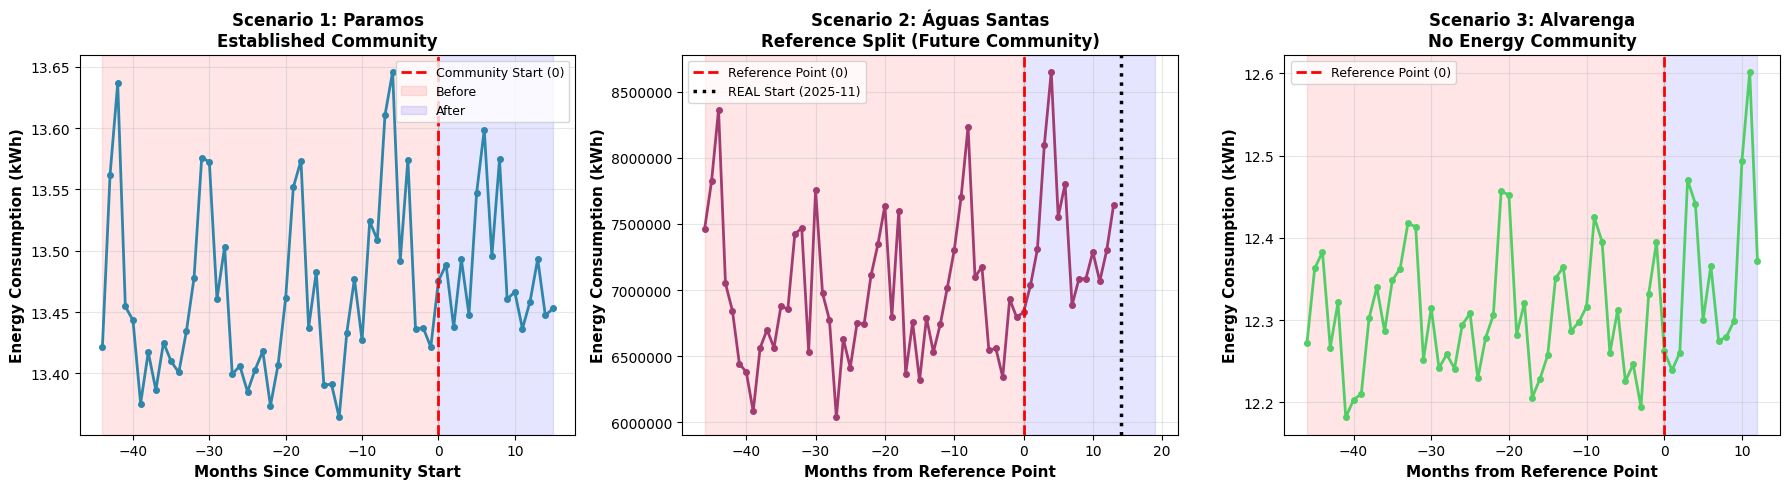

In [8]:

# Visualization

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scenario 1
if parish_with_both:
    data_with = month_con_full[month_con_full['parish_code'] == parish_with_both].sort_values('months_since_acc_cer')
    parish_name_with = data_with['parish_name'].iloc[0]
    
    ax = axes[0]
    ax.plot(data_with['months_since_acc_cer'], data_with['energy_kwh'], marker='o', linewidth=2, markersize=4, color='#2E86AB')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Community Start (0)')
    ax.axvspan(data_with['months_since_acc_cer'].min(), 0, alpha=0.1, color='red', label='Before')
    ax.axvspan(0, data_with['months_since_acc_cer'].max(), alpha=0.1, color='blue', label='After')
    ax.set_xlabel('Months Since Community Start', fontsize=11, fontweight='bold')
    ax.set_ylabel('Energy Consumption (kWh)', fontsize=11, fontweight='bold')
    ax.set_title(f'Scenario 1: {parish_name_with}\nEstablished Community', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.ticklabel_format(style='plain', axis='y')

# Scenario 2
if len(data_future_raw_grouped) > 0 and com_start_date and ref_date:
    data_future_raw_grouped['mapped_months'] = (data_future_raw_grouped['Date'].dt.year - ref_date.year) * 12 + (data_future_raw_grouped['Date'].dt.month - ref_date.month)
    ax = axes[1]
    ax.plot(data_future_raw_grouped['mapped_months'], data_future_raw_grouped['Energia Ativa'], 
           marker='o', linewidth=2, markersize=4, color='#A23B72')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Reference Point (0)')
    
    months_to_real_cer = (com_start_date.year - ref_date.year) * 12 + (com_start_date.month - ref_date.month)
    ax.axvline(x=months_to_real_cer, color='black', linestyle=':', linewidth=2.5, label=f'REAL Start ({com_start_date.strftime("%Y-%m")})')
    
    ax.axvspan(data_future_raw_grouped['mapped_months'].min(), 0, alpha=0.1, color='red')
    end_shade = max(data_future_raw_grouped['mapped_months'].max(), months_to_real_cer + 5)
    ax.axvspan(0, end_shade, alpha=0.1, color='blue')
    
    ax.set_xlabel('Months from Reference Point', fontsize=11, fontweight='bold')
    ax.set_ylabel('Energy Consumption (kWh)', fontsize=11, fontweight='bold')
    ax.set_title('Scenario 2: Águas Santas\nReference Split (Future Community)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.ticklabel_format(style='plain', axis='y')

# Scenario 3
if parish_without_acc:
    data_without = month_con_full[month_con_full['parish_code'] == parish_without_acc].sort_values('date')
    parish_name_without = data_without['parish_name'].iloc[0]
    
    ax = axes[2]
    ax.plot(data_without['months_since_acc_cer'], data_without['energy_kwh'], 
           marker='o', linewidth=2, markersize=4, color='#51CF66')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Reference Point (0)')
    ax.axvspan(data_without['months_since_acc_cer'].min(), 0, alpha=0.1, color='red')
    ax.axvspan(0, data_without['months_since_acc_cer'].max(), alpha=0.1, color='blue')
    ax.set_xlabel('Months from Reference Point', fontsize=11, fontweight='bold')
    ax.set_ylabel('Energy Consumption (kWh)', fontsize=11, fontweight='bold')
    ax.set_title(f'Scenario 3: {parish_name_without}\nNo Energy Community', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.savefig('3_AllDataAgregation_output/parish_scenarios_plot.png', dpi=300, bbox_inches='tight')
print("Saved: parish_scenarios_plot.png")
plt.show()
